# Question 1

In [ ]:
!pip install ipympl numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


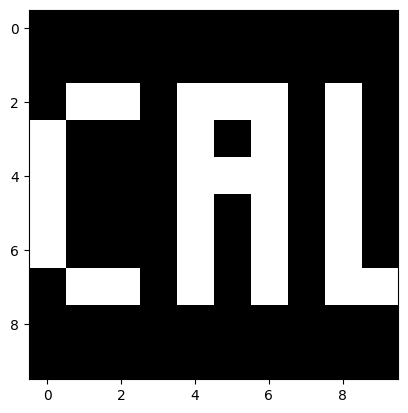

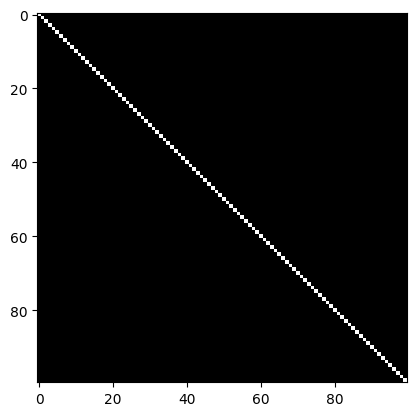

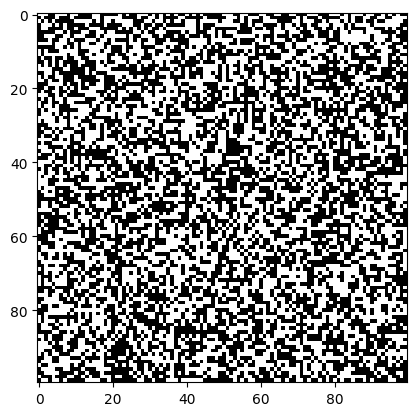

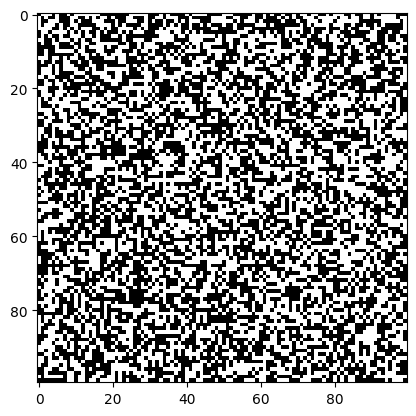

In [74]:
# Let's load some data to start off with.
H3 = np.loadtxt("cond_10e6.txt", delimiter=',').reshape(100,100)
H2 = np.loadtxt("cond_1e3.txt", delimiter=',').reshape(100,100)
H1 = np.eye(100)
img = np.loadtxt("image.txt", delimiter=',').reshape(10,10)

# The code below displays the image and the set of masks.
plt.figure(0)
plt.imshow(img,cmap='gray')
plt.figure(1)
plt.imshow(H1,cmap='gray')
plt.figure(2)
plt.imshow(H2,cmap='gray')
plt.figure(3)
plt.imshow(H3,cmap='gray')

In [75]:
# We'll use numpy.random to make some noise.
noise = np.random.normal(0.5,0.1)

# Lets compute the measurement vector s for each matrix, i.e. s = Hi + w (w is the noise vector).
s1 = H1.dot(img.reshape(100)) + noise
s2 = H2.dot(img.reshape(100)) + noise
s3 = H3.dot(img.reshape(100)) + noise

Is the matrix invertible? True
The smallest eigenvalue is: 1.0
Number of eigenvectors: 100


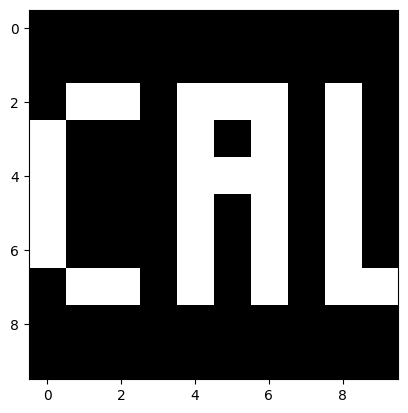

In [76]:
# First, let's compute our first recovered image, imgrec1, from the measurement vector s1. 
# Since s1 was generated using H1, we can apply the inverse of H1.
# We also want to find the minimum eigenvalue of H1.
imgrec1 = np.linalg.inv(H1).dot(s1)
eigenvalues1 = np.linalg.eig(H1)[0]
print("Is the matrix invertible?", abs(np.linalg.det(H1)) > 0.5)
print("The smallest eigenvalue is:", min(np.absolute(eigenvalues1)))
print("Number of eigenvectors:", len(eigenvalues1))
plt.imshow(imgrec1.reshape(10,10), cmap='gray')

Is the matrix invertible? True
The smallest eigenvalue is: 0.2951636330862997
Number of eigenvectors: 100


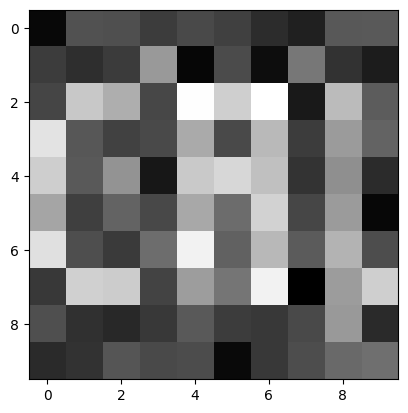

In [77]:
# Next, let's compute our recovered image imgrec2 from the measurement vector s2. 
# We also want to find the minimum eigenvalue of H2.
imgrec2 = np.linalg.inv(H2).dot(s2)
eigenvalues2 = np.linalg.eig(H2)[0]
print("Is the matrix invertible?", abs(np.linalg.det(H2)) > 0.5)
print("The smallest eigenvalue is:", min(np.absolute(eigenvalues2)))
print("Number of eigenvectors:", len(eigenvalues2))
plt.imshow(imgrec2.reshape(10,10), cmap='gray')

Is the matrix invertible? True
The smallest eigenvalue is: 1.2184217524713281e-05
Number of eigenmathbftors: 100


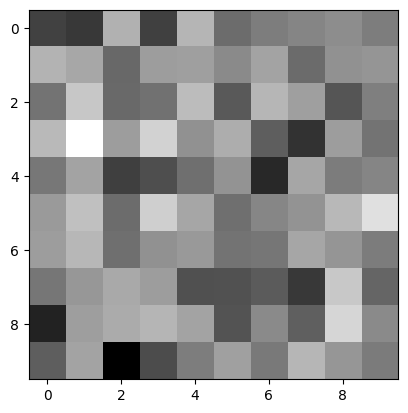

In [78]:
# Finally, let's compute our recovered image imgrec3 from the measurement mathbftor s3.
# We also want to find the minimum eigenvalue of H3.
imgrec3 = np.linalg.inv(H3).dot(s3)
eigenvalues3 = np.linalg.eig(H3)[0]
print("Is the matrix invertible?", abs(np.linalg.det(H3)) > 0.5)
print("The smallest eigenvalue is:", min(np.absolute(eigenvalues3)))
print("Number of eigenmathbftors:", len(eigenvalues3))
plt.imshow(imgrec3.reshape(10,10), cmap='gray')

# Question 4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Smooooooth Force Sequence

### Constraints and Objective

We consider a unit mass initially at rest ($v_i = 0$) at position $p_i = 0$. We apply a sequence of 10 forces $\mathbf{f} = [f_1, \dots, f_{10}]^T$, each for 1 second. The goal is to reach final position $p_f = 1$ with zero final velocity ($v_f = 0$).

The constraints are $\mathbf{C} \mathbf{f} = \mathbf{d}$, and the smoothness objective minimizes $|\mathbf{A} \mathbf{f}|^2$, penalizing differences between consecutive forces (with $f_0 = 0$ and $f_{11} = 0$).

#### TODO: Fill in the Constraint Matrix and Vector $\mathbf{C}$, $\mathbf{d}$, and Objective Matrix $\mathbf{A}$:

In [ ]:
# 1. Define the number of time steps
n = 10

# 2. Build the constraint matrix C and vector d
C = np.zeros((2, n))
C[0, :] = 1.0
C[1, :] = np.arange(19, -1, -2) / 2.0   # [19/2, 17/2, ..., 1/2]
d = np.array([0.0, 1.0])

# 3. Build the objective matrix A
A = np.zeros((n+1, n))
A[0, 0] = 1.0
for i in range(1, n):
    A[i, i-1] = -1.0
    A[i, i] = 1.0
A[n, n-1] = -1.0

print('Shape of C:', C.shape)
print('Shape of A:', A.shape)
print('Shape of d:', d.shape)

Shape of C: (2, 10)
Shape of A: (11, 10)
Shape of d: (2,)


### Solving the Constrained Least Squares Problem
We now solve for the optimal force sequence $\mathbf{f}$ that minimizes smoothness while satisfying the physical constraints:

$$
\text{minimize } \|\mathbf{A}\mathbf{f}\|^2 \quad \text{subject to} \quad \mathbf{C}\mathbf{f} = \mathbf{d}.
$$

This is a quadratic program with equality constraints. We construct and solve the KKT system:

$$
\begin{bmatrix}
2\mathbf{A}^T\mathbf{A} & \mathbf{C}^T \\
\mathbf{C} & \mathbf{0}
\end{bmatrix}
\begin{bmatrix} \mathbf{f} \\ \boldsymbol{\lambda} \end{bmatrix}
=
\begin{bmatrix} \mathbf{0} \\ \mathbf{d} \end{bmatrix}.
$$

In [ ]:
# Construct KKT block matrix
KKT_matrix = np.block([
    [2 * A.T @ A, C.T],
    [C, np.zeros((2, 2))]
])

# Construct right-hand side
rhs = np.concatenate([np.zeros(n), d])

# Solve the linear system
solution = np.linalg.solve(KKT_matrix, rhs)
f = solution[:n]   # extract the 10 forces

print('Optimal force sequence:')
print(np.round(f, 4))

Optimal force sequence:
[ 0.035   0.049   0.0466  0.0326  0.0117 -0.0117 -0.0326 -0.0466 -0.049
 -0.035 ]


### Simulating the Physics & Plotting
With the forces applied in 1‑second intervals, we can compute the exact position and velocity at any continuous time $t$ using Newton’s laws ($a = F/m$, with $m=1$).

We first compute the discrete states at integer times, then interpolate for a smooth plot.

#### TODO: Take a screenshot of the output graphs, and include them in your HW written responses

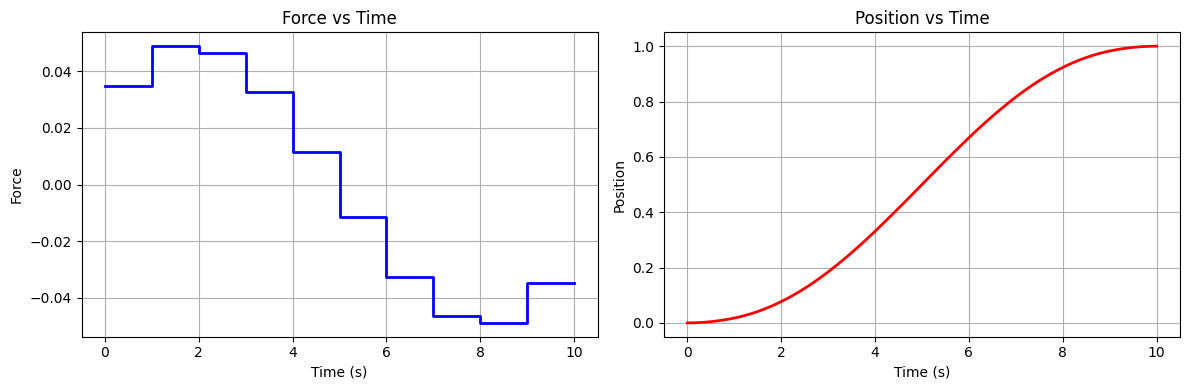

In [ ]:
dt = 0.05
times = np.arange(0, 10 + dt, dt)
positions = []
velocities = []
forces = []

# Pre-calculate discrete state at the start of each 1s interval
p_discrete = [0.0]
v_discrete = [0.0]
for force in f:
    v_next = v_discrete[-1] + force * 1.0
    p_next = p_discrete[-1] + v_discrete[-1] * 1.0 + 0.5 * force * (1.0**2)
    v_discrete.append(v_next)
    p_discrete.append(p_next)

# Interpolate for continuous plotting
for t in times:
    if t == 10.0:
        step = 9
        local_t = 1.0
    else:
        step = int(np.floor(t))
        local_t = t - step
    
    current_force = f[step]
    forces.append(current_force)
    
    # Kinematics: p = p0 + v0*t + 0.5*a*t^2
    v = v_discrete[step] + current_force * local_t
    p = p_discrete[step] + v_discrete[step] * local_t + 0.5 * current_force * (local_t**2)
    
    velocities.append(v)
    positions.append(p)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set_facecolor('white')
ax2.set_facecolor('white')

plot_times = np.arange(11)
plot_forces = np.append(f, f[-1])
ax1.step(plot_times, plot_forces, where='post', color='blue', linewidth=2)
ax1.set_title('Force vs Time')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Force')
ax1.grid(True)

ax2.plot(times, positions, color='red', linewidth=2)
ax2.set_title('Position vs Time')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Position')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Block Animation
Let’s watch the block move from $x=0$ to $x=1$ under the optimal force sequence.

In [ ]:
import numpy as np  # for cos, sin

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
ax.set(xlim=(-0.1, 1.2), ylim=(-0.3, 0.3))
fig.set_facecolor('white')

# Minimalist track and markers
ax.plot([-0.1, 1.1], [0, 0], 'black', [0, 0], [-0.05, 0.05], 'green', [1, 1], [-0.05, 0.05], 'red', lw=1)
ax.text(0, -0.08, 'Start', ha='center', va='top', c='green')
ax.text(1, -0.08, 'End', ha='center', va='top', c='red')

# Create minimalist black cube
block = plt.Rectangle((-0.04, 0), 0.08, 0.08, fc='black')
ax.add_patch(block)

# Action lines for flashing shape
line1, = ax.plot([], [], 'grey', lw=1)
line2, = ax.plot([], [], 'grey', lw=1)

# Left-aligned UI texts
kw = dict(transform=ax.transAxes, ha='left')
time_text = ax.text(0.0, 0.90, '', va='top', **kw)
force_text = ax.text(0.0, 0.18, '', va='bottom', **kw)
pos_text = ax.text(0.0, 0.05, '', va='bottom', **kw)

# Pre-calculate flash intensities (no fading)
flashes, last_t, last_f = [], 0, forces[0] if len(forces) else 0
for t, f in zip(times, forces):
    if abs(f - last_f) > 1e-6:
        last_t, last_f = t, f
    flashes.append(1 if (t - last_t) <= 0.2 else 0)

def animate(i):
    x, t, f, flash = positions[i], times[i], forces[i], flashes[i]
    block.set_xy((x - 0.04, 0))
    time_text.set_text(f'Time:     {t:05.2f}s')
    force_text.set_text(f'Force:    {f:+.4f}')
    pos_text.set_text(f'Position: {x:+.4f}')

    if flash:
        sign = -1 if f >= 0 else 1          # -1 = left corner, 1 = right corner
        corner_x = x + sign * 0.04           # corner x coordinate
        corner_y = 0.08                      # corner y coordinate

        # Outward direction angle from cube center to corner
        if sign > 0:
            angle_out = np.pi / 4            # 45° for right corner
        else:
            angle_out = 3 * np.pi / 4        # 135° for left corner

        # Parameters for the two lines
        d_start = 0.04                        # distance from corner to line start points
        line_length = 0.02                     # length of each line (shorter than d_start)
        spread = np.pi / 9                     # 20° spread between the two directions

        # Directions for the two lines (symmetric around angle_out)
        angle1 = angle_out + spread
        angle2 = angle_out - spread

        # Start points (farther from corner)
        start1_x = corner_x + d_start * np.cos(angle1)
        start1_y = corner_y + d_start * np.sin(angle1)
        start2_x = corner_x + d_start * np.cos(angle2)
        start2_y = corner_y + d_start * np.sin(angle2)

        # End points (closer to corner, along the same directions)
        end1_x = corner_x + (d_start - line_length) * np.cos(angle1)
        end1_y = corner_y + (d_start - line_length) * np.sin(angle1)
        end2_x = corner_x + (d_start - line_length) * np.cos(angle2)
        end2_y = corner_y + (d_start - line_length) * np.sin(angle2)

        # Draw the lines from start to end (both pointing toward the corner)
        line1.set_data([start1_x, end1_x], [start1_y, end1_y])
        line2.set_data([start2_x, end2_x], [start2_y, end2_y])

        # Color the force text according to direction
        if sign < 0:
            force_text.set_c('green')
        else:
            force_text.set_c('red')
    else:
        force_text.set_c('black')
        line1.set_data([], [])
        line2.set_data([], [])

    return block, time_text, force_text, pos_text, line1, line2

anim = FuncAnimation(fig, animate, frames=len(times), interval=dt*1000, blit=True)
plt.close()

# Display interactive animation
HTML(anim.to_jshtml())

### TODO: Reflection Questions
Please answer the following questions. You may answer them outside of this notebook.

**1. Why does the objective function** $\sum (f_{k+1} - f_k)^2$
**encourage a smooth force sequence? What types of force sequences does this objective strongly penalize?**
> *Answer:*  
The objective penalizes the squared difference between consecutive forces, so large jumps between time steps produce a large cost! This encourages the force to change gradually, resulting in a smooth profile. Sequences with sudden spikes, sharp sign changes, or oscillations are strongly penalized because they create large differences between neighbouring forces.

**2. What would happen if we removed the constraints $\mathbf{C}\mathbf{f} = \mathbf{d}$, and performed an unconstrained optimization for minimising the objective? What would this mean physically for the motion of the mass?**

_**Hint:** recall, what do these constraints define? How would removing them change the optimal trajectory?_

> *Answer:*  
The constraints enforce that the mass reaches the target position and stops with zero velocity. Without them, the optimization only minimizes the smoothness objective. The minimum occurs when all force differences are zero, giving a constant force sequence. Since the boundaries require zero force, the optimal solution becomes $\mathbf{f}=0$. Physically, this means no force is applied and the mass never moves.

**3. Examine the resulting Force vs. Time and Distance vs. Time plots. Does the optimal force profile match your physical intuition for how you would move the mass by hand? Explain why or why not.**

> *Answer:*  
Yes. To move the mass and stop it at the target, we would first apply a positive force to accelerate it, then gradually reduce the force and apply a negative force to slow it down. The smooth ramping of the force matches this intuition and produces a distance curve where the mass speeds up and then slows down before stopping.